In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read tsv
df = pd.read_csv(
    "/workspaces/Effector-Structure-Prediction/04_results_tsv/pdb_metadata_af3.tsv",
    sep="\t"
)

In [4]:
# Formulas for one variable plots  
def plot_subplots (tm_columns: List, titles: List, figure_title:str , histogram=None, boxplot=None):
    """
    Set histogram or boxplot to True to plot.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12,5), sharex=True, sharey=True)

    for ax, col, title in zip(axes, tm_columns, titles):

        if histogram:
            ax.hist(
                df[col].dropna(),
                bins=20,
                edgecolor="black"
            )

            ax.set_xlim(0, 1)

        elif boxplot:
            ax.boxplot(
                df[col].dropna(),
                vert=True,
                patch_artist=True
            )

        ax.set_title(title)
        ax.set_xlabel("TM-score")
        ax.set_ylabel("Count")
        
        ax.grid(alpha=0.3)

    fig.suptitle(figure_title)
    plt.tight_layout()
    plt.show()

In [5]:
tm_columns = [
    "TM_score_crystal_esm",
    "TM_score_crystal_af2",
    "TM_score_crystal_af3",
]

titles = [
    "ESMFold",
    "AlphaFold2",
    "AlphaFold3",
]

figure_title="Distribution of TM-scores"

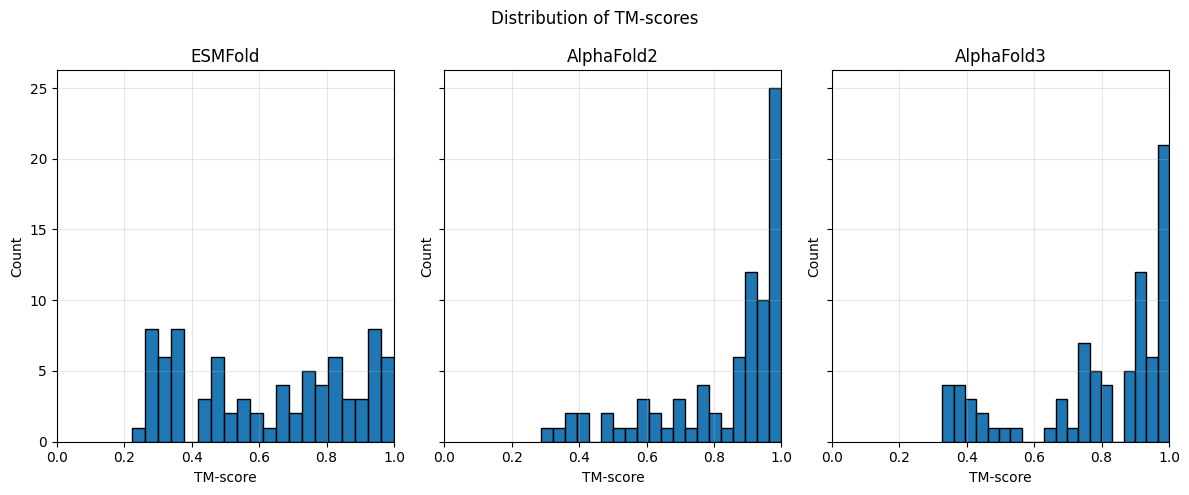

In [6]:
plot_subplots(tm_columns, titles, figure_title , True, None)

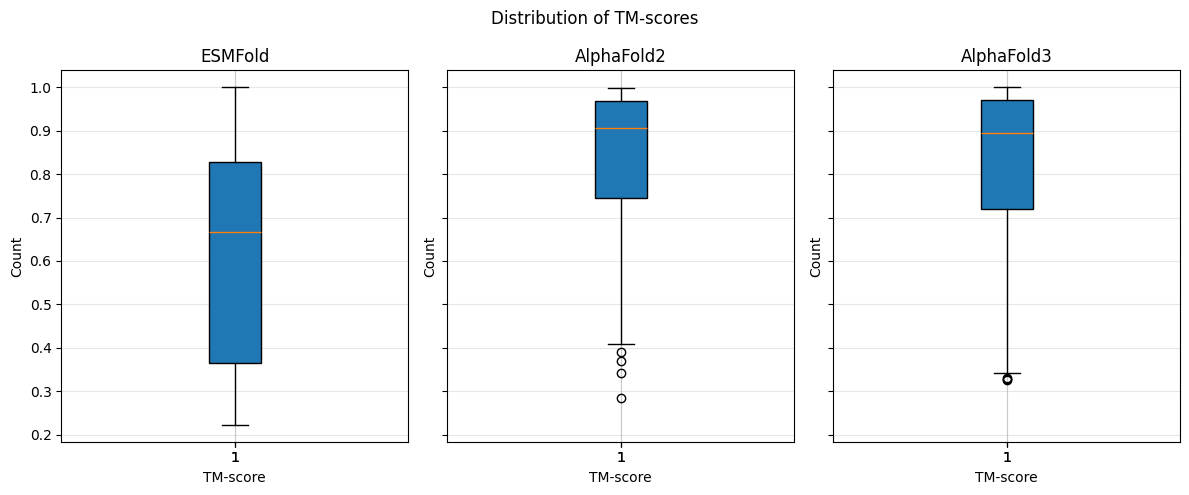

In [7]:
plot_subplots(tm_columns, titles, figure_title , None, True)

In [8]:
# For categorical data, use list of most frequent groups to color overlay the graphs

def simplify_family(family):
    family = str(family).strip()
    return family if family in families else "Other"

# Choose structural families to color 
families = {
    "AvrSr35-like",
    "FOLD",
    "KP4-like",
    "LARS",
    "MAX",
    "RALPH",
    "ToxA-like",
}

df["Structural_family_simplified"] = df[
    "Structural family (inferred from La Naour Vernet et al. (2025))"
].apply(simplify_family)

print(df["Structural_family_simplified"].value_counts())


Structural_family_simplified
Other           29
MAX             26
RALPH            7
ToxA-like        6
AvrSr35-like     4
LARS             4
FOLD             3
KP4-like         2
Name: count, dtype: int64


In [9]:
# All Pyricularia oryzae are considered Magnaporthe oryzae
df["Organism"] = (
    df["Organism"]
    .str.lower()
    .str.replace(
        "pyricularia oryzae",
        "magnaporthe oryzae",
        regex=False
    )
)

# Which organisms to colour
families = {
    "blumeria hordei",
    "fusarium oxysporum",
    "magnaporthe oryzae",
    "puccinia graminis",
    "pyrenophora tritici-repentis",
}

def simplify_organism(org):
    org = str(org).lower()

    for family in families:
        if family in org:
            return family

    return "other"

df["Organism_simplified"] = df["Organism"].apply(simplify_organism)

print(df["Organism_simplified"].value_counts())

Organism_simplified
other                           33
magnaporthe oryzae              26
fusarium oxysporum               8
puccinia graminis                6
pyrenophora tritici-repentis     4
blumeria hordei                  4
Name: count, dtype: int64


In [10]:
def simplify_method(method):
    method = str(method).lower().strip()

    if "nmr" in method:
        return "Solution NMR"

    elif "x-ray" in method or "xray" in method or "x ray" in method:
        return "X-ray"

    elif "electron" in method or "em" in method:
        return "Electron microscopy"

    else:
        return "Other"


df["Method_simplified"] = df["Method"].apply(simplify_method)

print(df["Method_simplified"].value_counts())

Method_simplified
X-ray                  59
Solution NMR           16
Electron microscopy     4
Other                   2
Name: count, dtype: int64


In [11]:
comparisons = [
    ("TM_score_crystal_esm", "TM_score_crystal_af2", "ESM vs AF2"),
    ("TM_score_crystal_esm", "TM_score_crystal_af3", "ESM vs AF3"),
    ("TM_score_crystal_af2", "TM_score_crystal_af3", "AF2 vs AF3"),
]

In [12]:
def plot_categorical_tm_scores(
    df,
    category_column,
    category_order,
    comparisons,
    legend_title,
    figure_title,
):
    colors = plt.cm.tab10.colors
    category_colors = {
        category: colors[i % len(colors)]
        for i, category in enumerate(category_order)
    }

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5),
        sharex=True,
        sharey=True,
    )

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        for category in category_order:

            subset = df[df[category_column] == category]

            ax.scatter(
                subset[xcol],
                subset[ycol],
                label=category,
                color=category_colors[category],
                s=50,
                alpha=0.8,
            )

        ax.plot([0, 1], [0, 1], "--", color="black")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title(title)
        ax.grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title=legend_title,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
    )

    fig.suptitle(figure_title, fontsize=14)

    plt.tight_layout()
    plt.show()

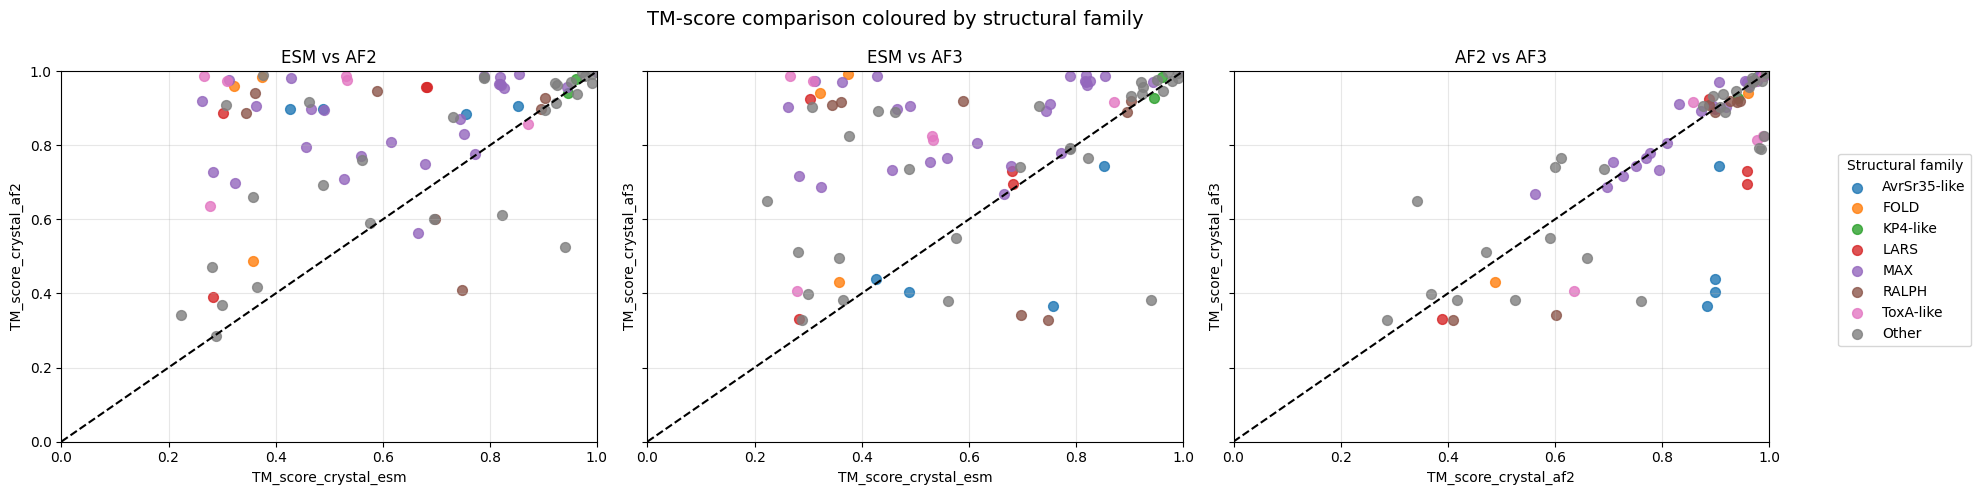

In [13]:
family_order = [
    'AvrSr35-like',
    'FOLD',
    'KP4-like',
    'LARS',
    'MAX',
    'RALPH',
    'ToxA-like',
    'Other'
]

plot_categorical_tm_scores(
    df=df,
    category_column="Structural_family_simplified",
    category_order=family_order,
    comparisons=comparisons,
    legend_title="Structural family",
    figure_title="TM-score comparison coloured by structural family",
)

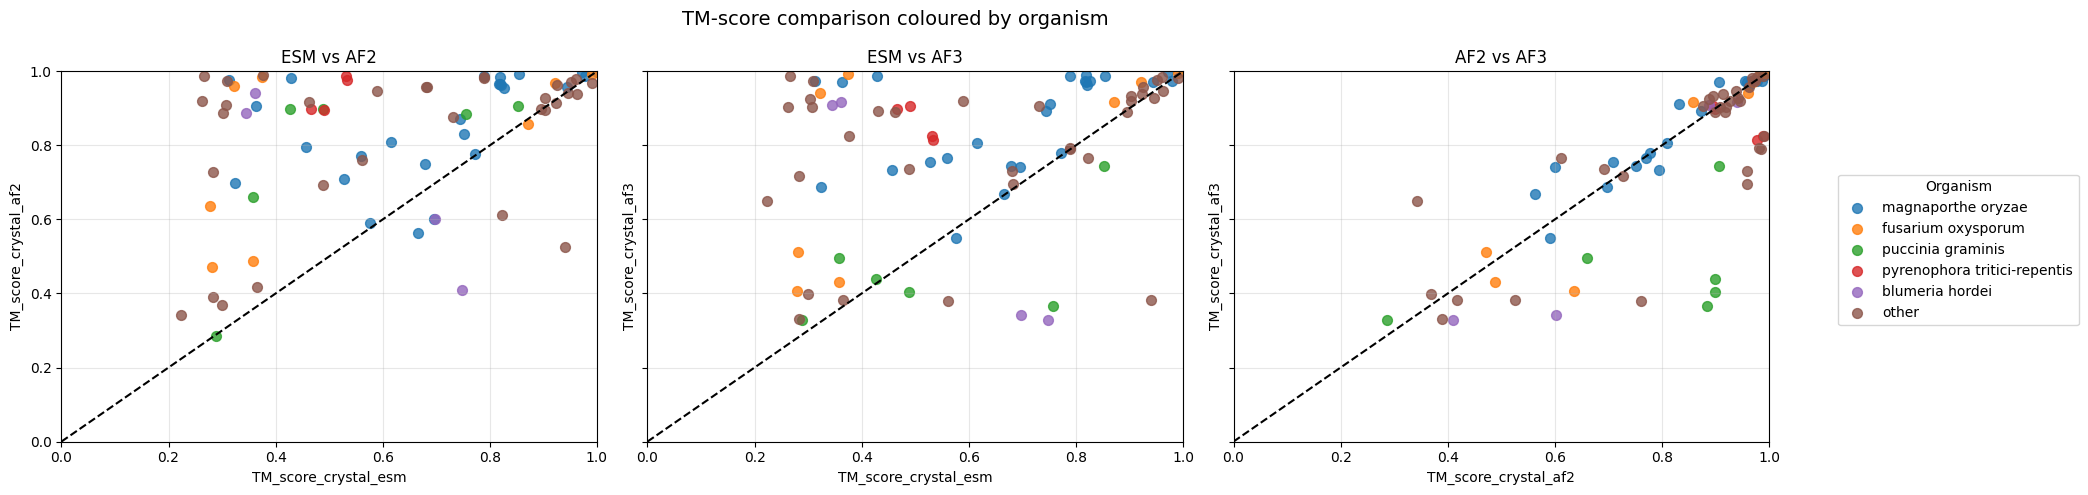

In [14]:
organism_order = [
    'magnaporthe oryzae',
    'fusarium oxysporum',
    'puccinia graminis',
    'pyrenophora tritici-repentis',
    'blumeria hordei',
    'other'
]
plot_categorical_tm_scores(
    df=df,
    category_column="Organism_simplified",
    category_order=organism_order,
    comparisons=comparisons,
    legend_title="Organism",
    figure_title="TM-score comparison coloured by organism",
)

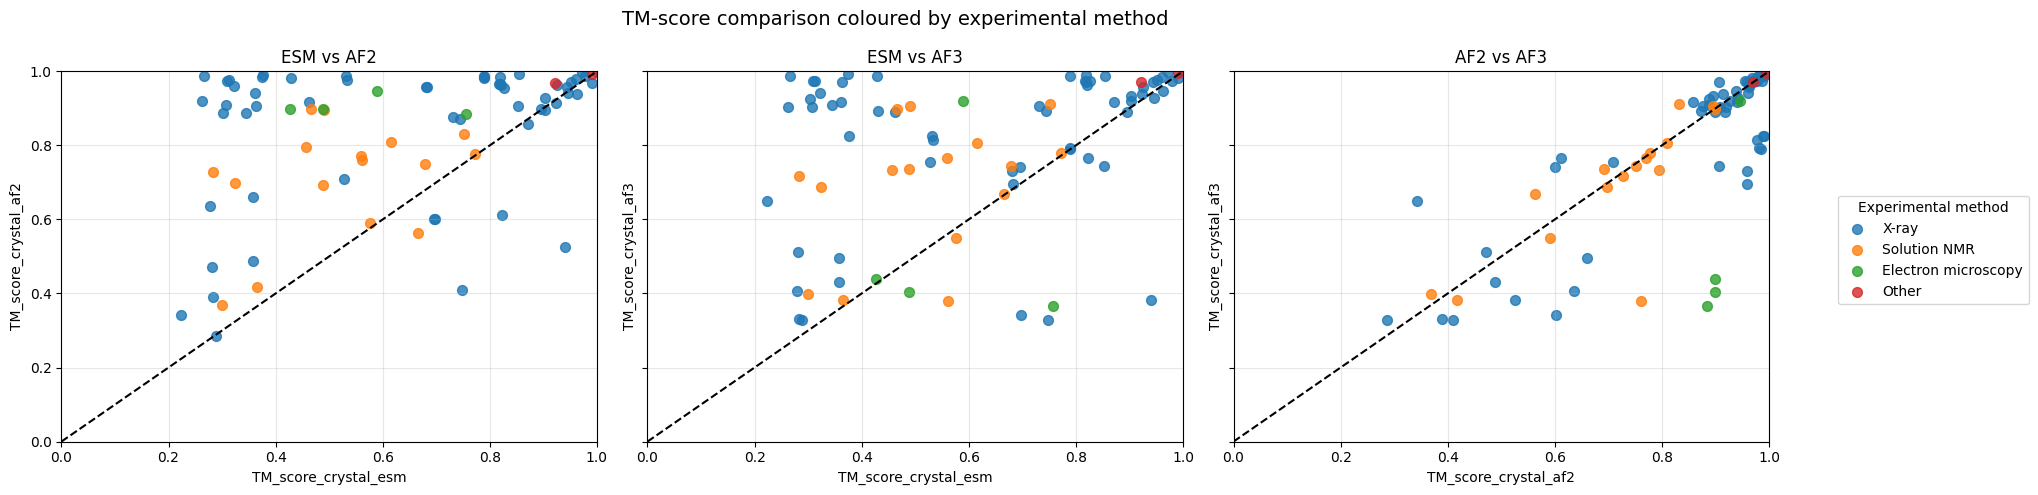

In [15]:
method_order = [
    "X-ray",
    "Solution NMR",
    "Electron microscopy",
    "Other",
]

plot_categorical_tm_scores(
    df=df,
    category_column="Method_simplified",
    category_order=method_order,
    comparisons=comparisons,
    legend_title="Experimental method",
    figure_title="TM-score comparison coloured by experimental method",
)

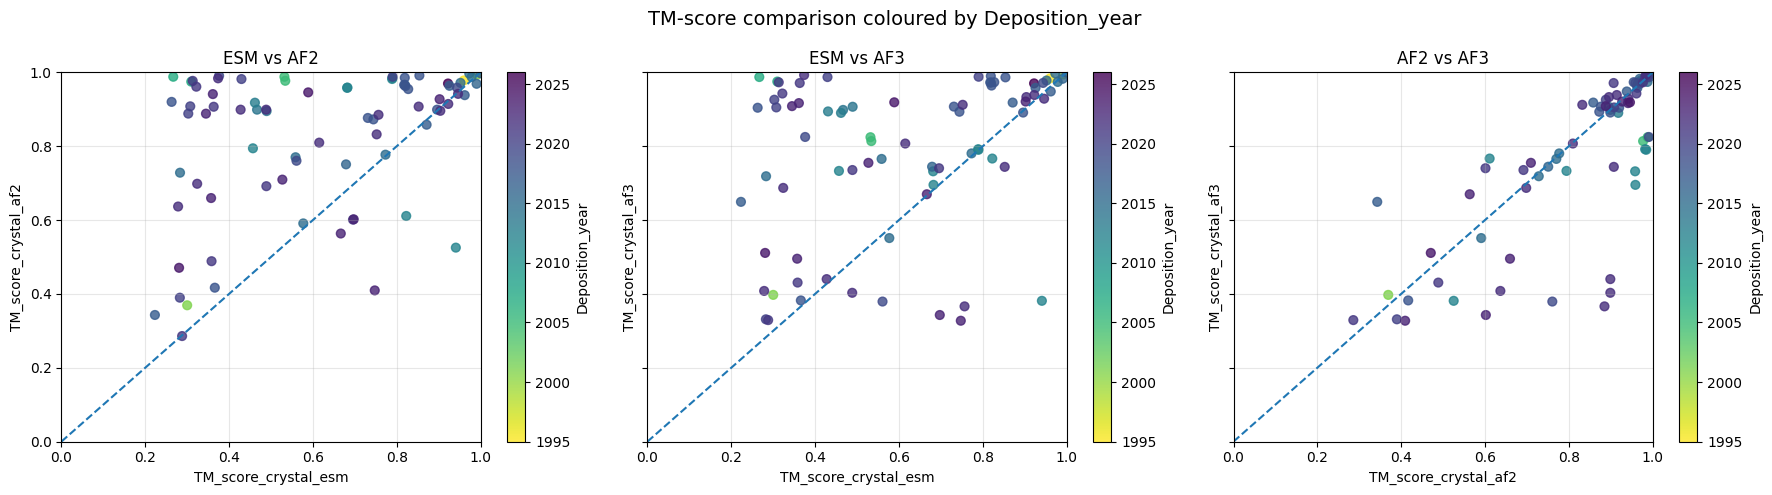

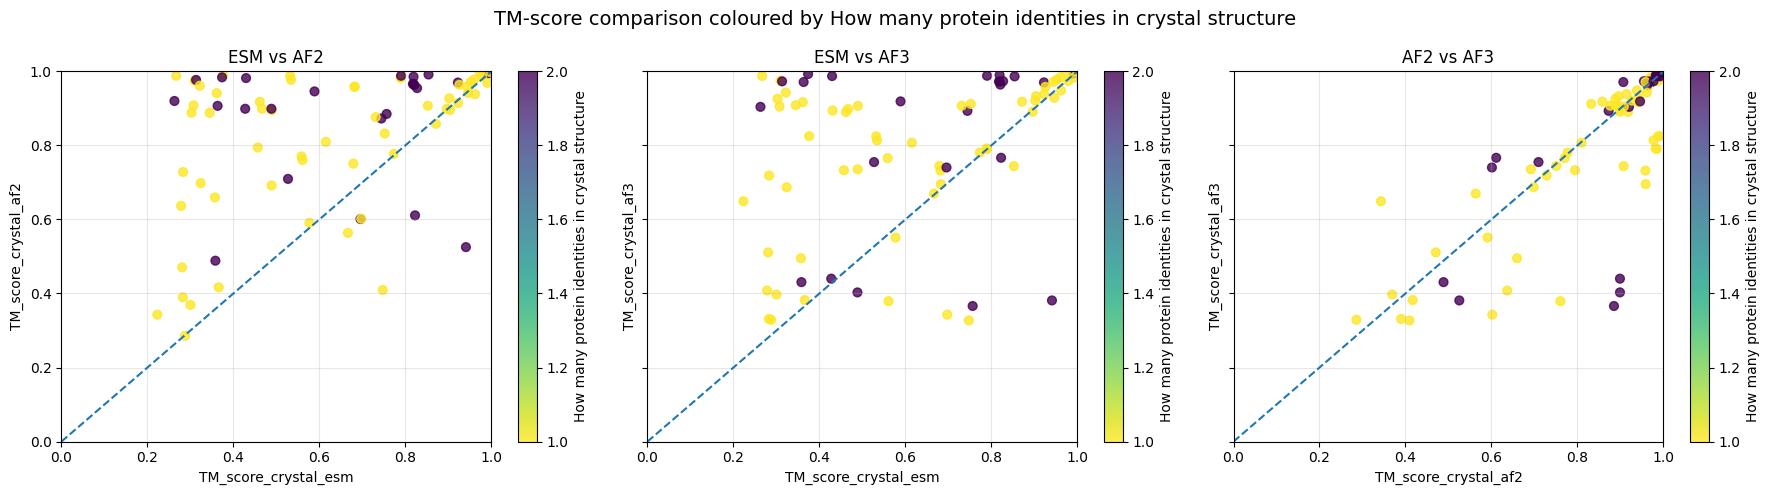

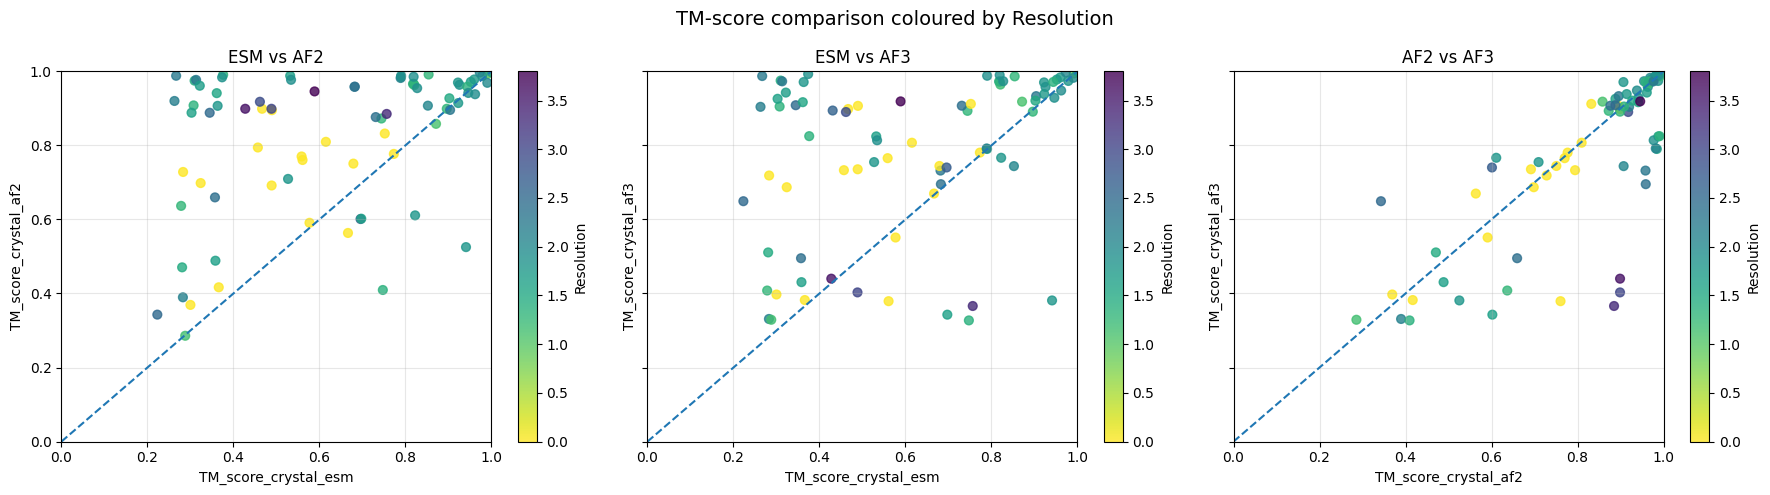

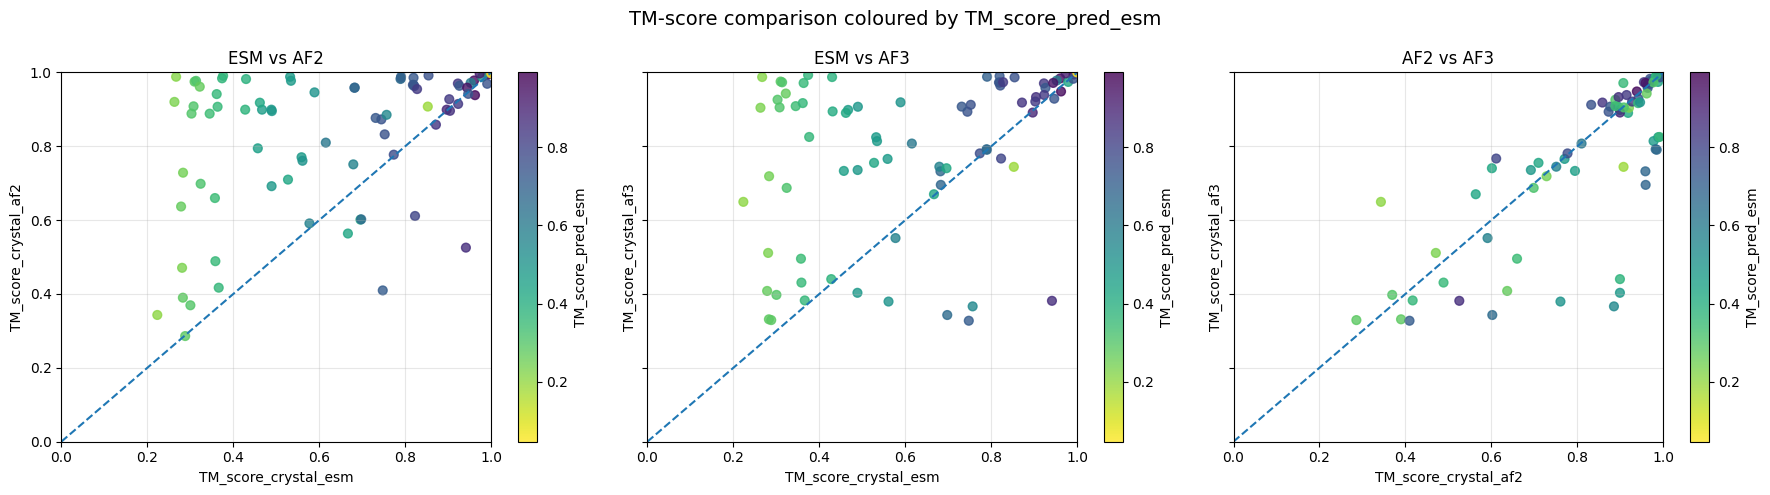

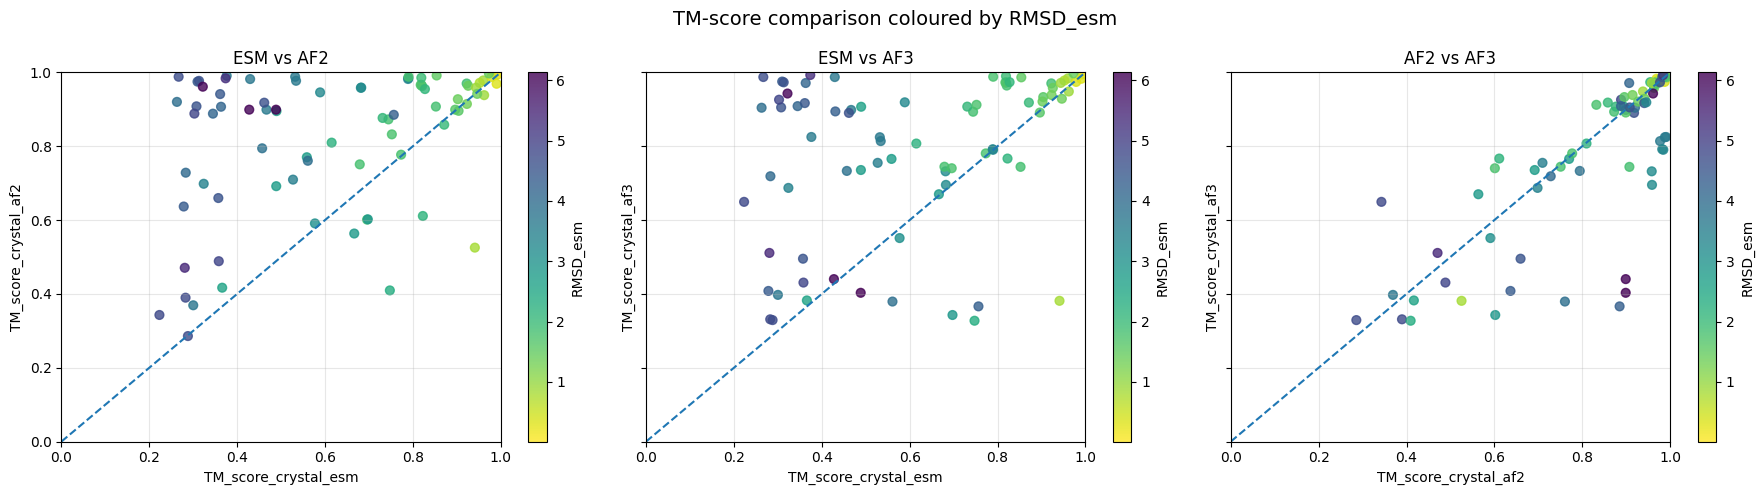

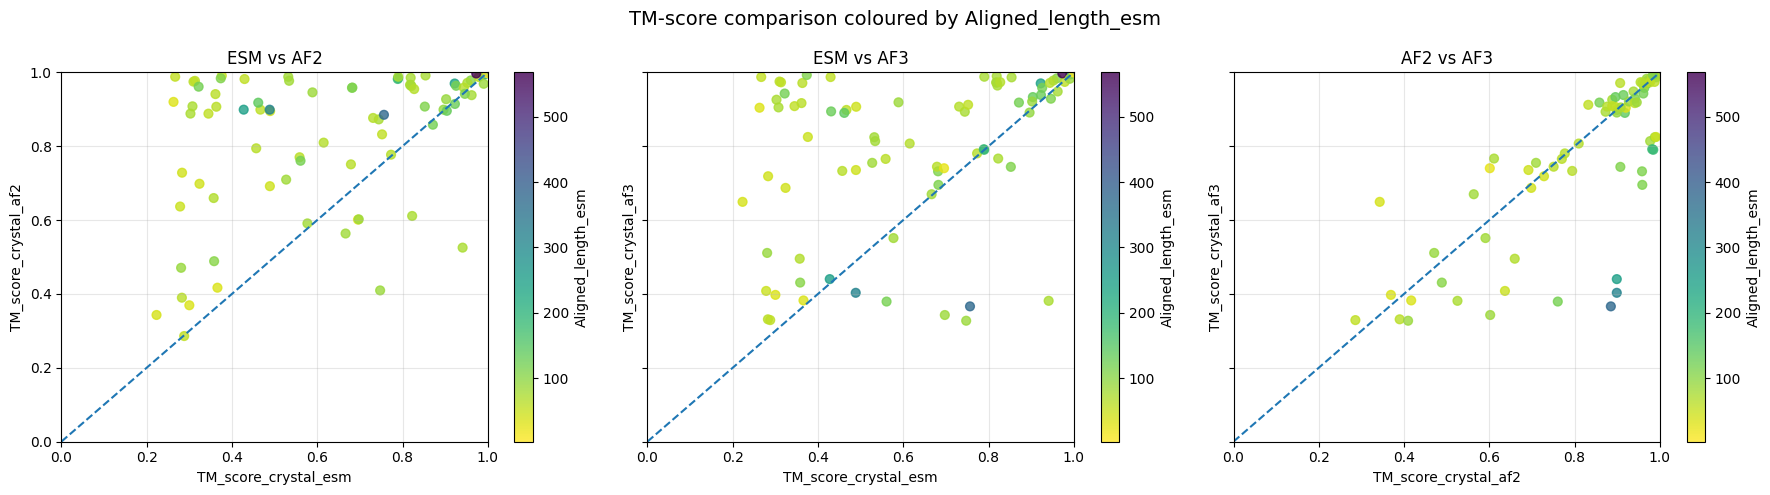

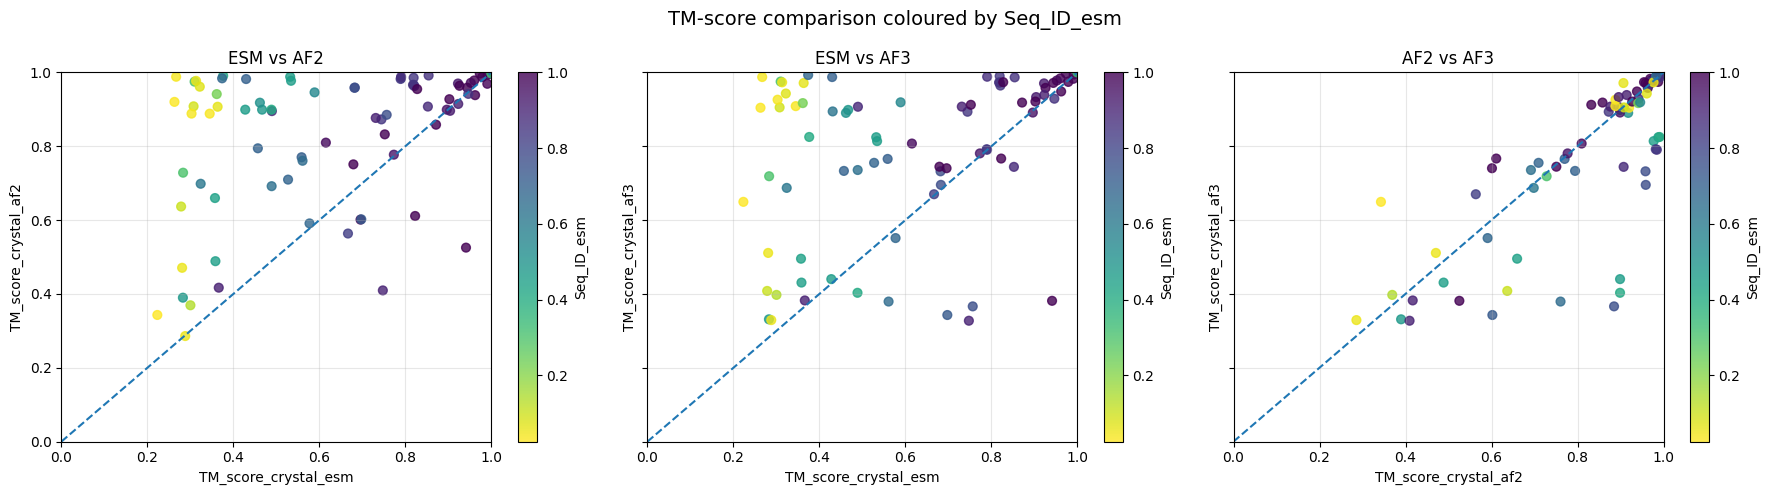

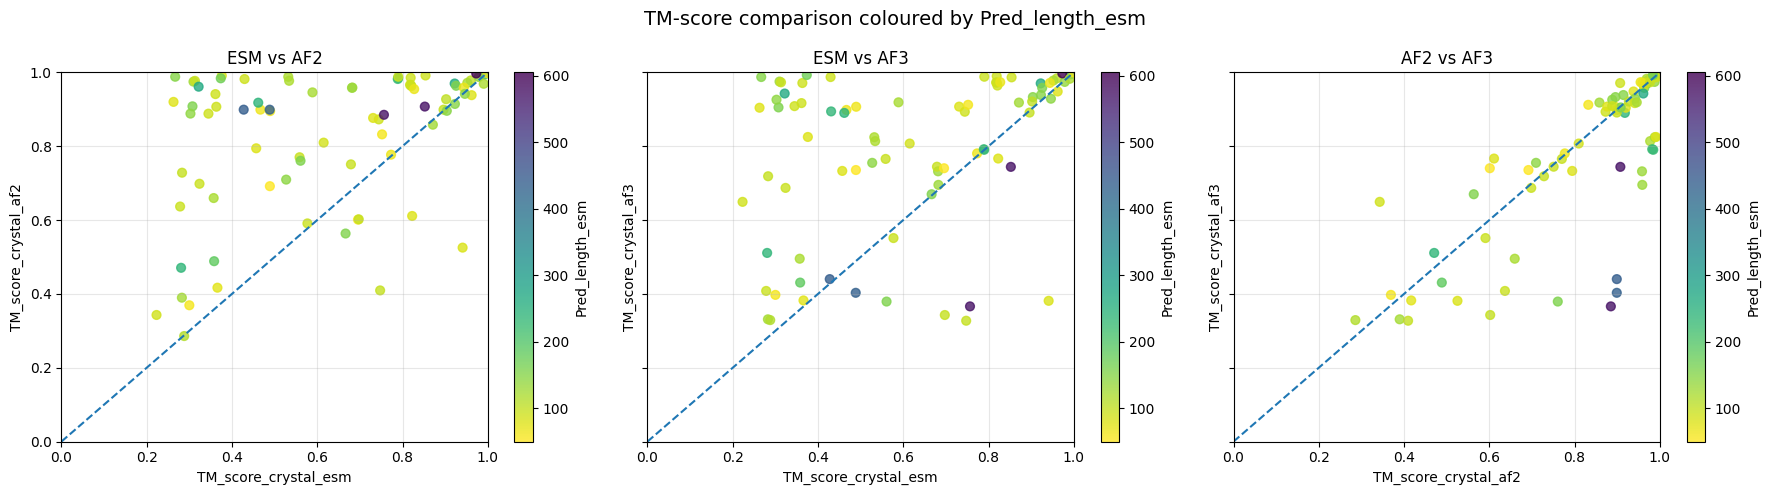

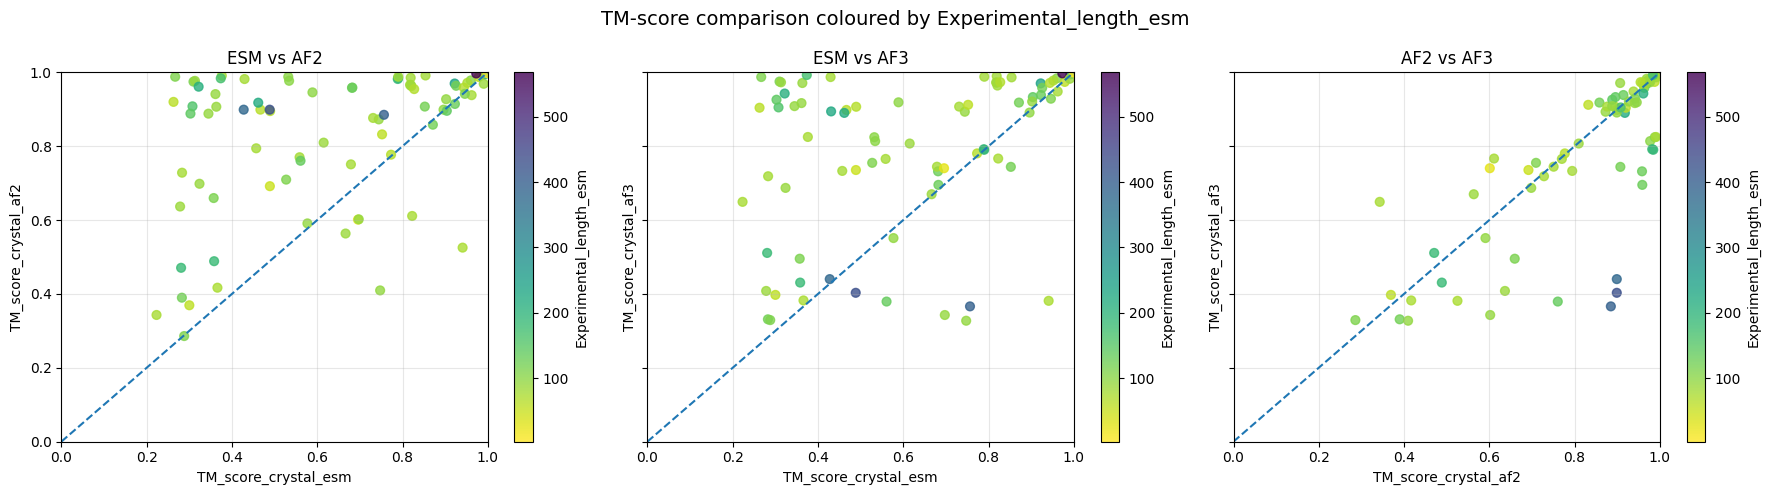

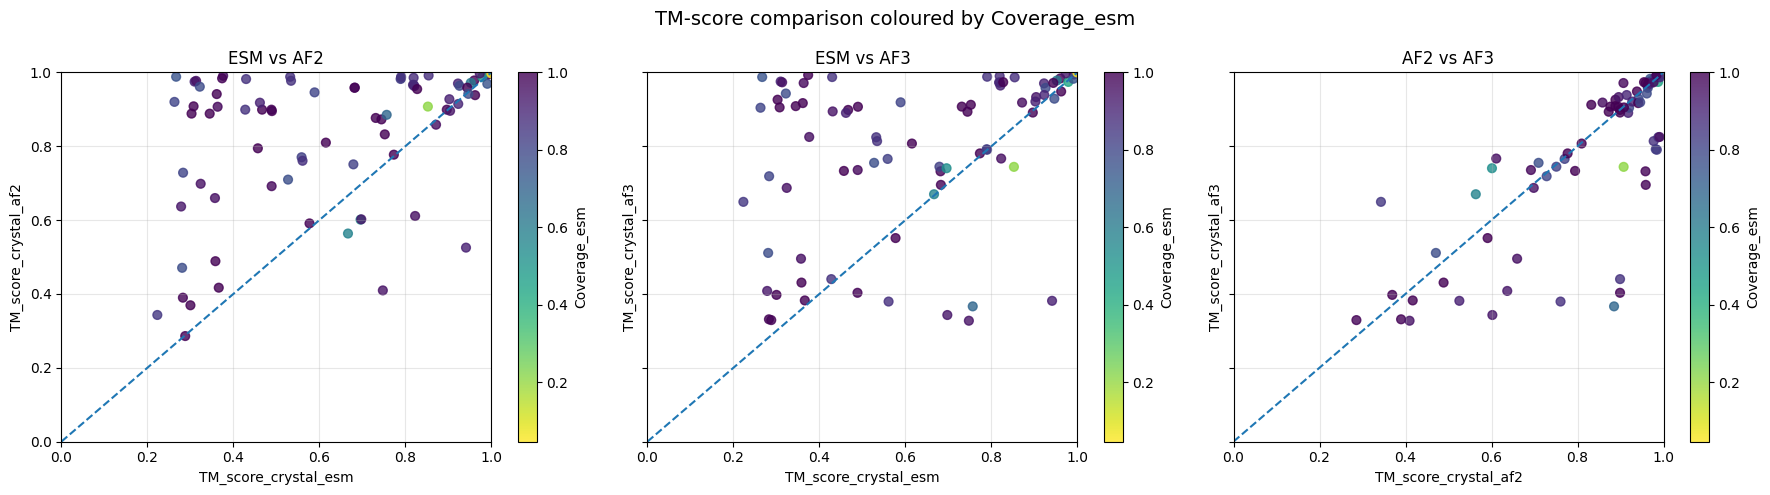

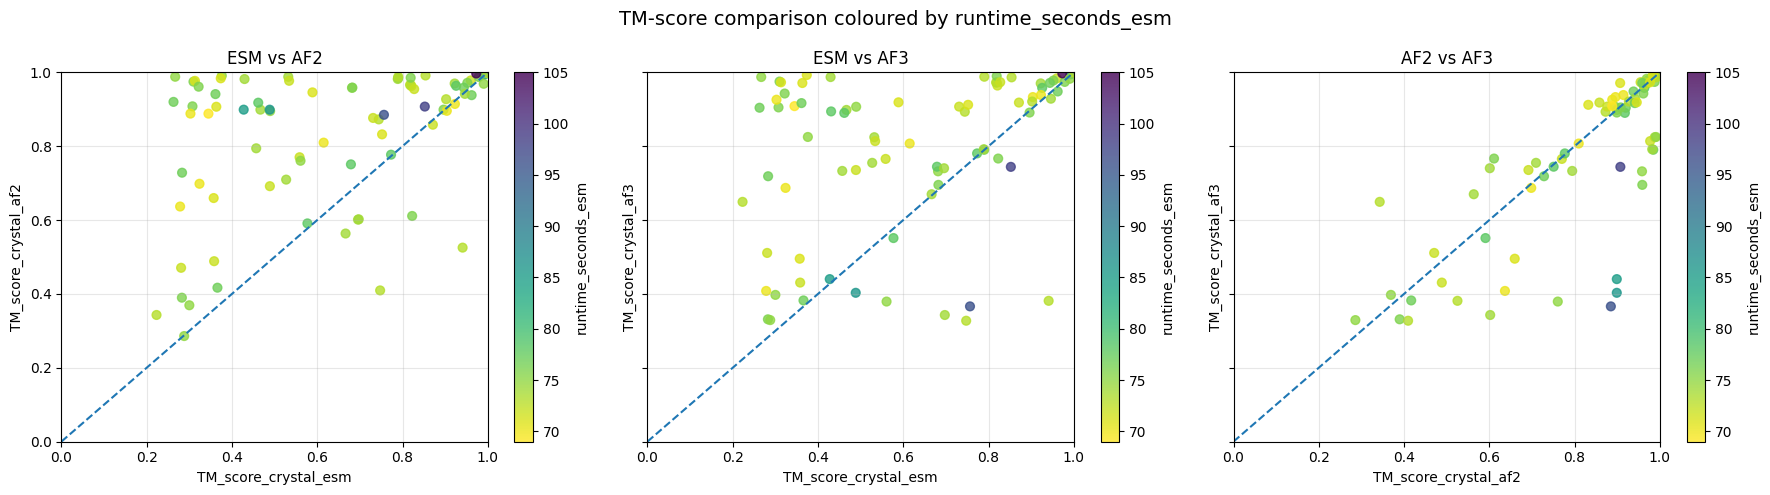

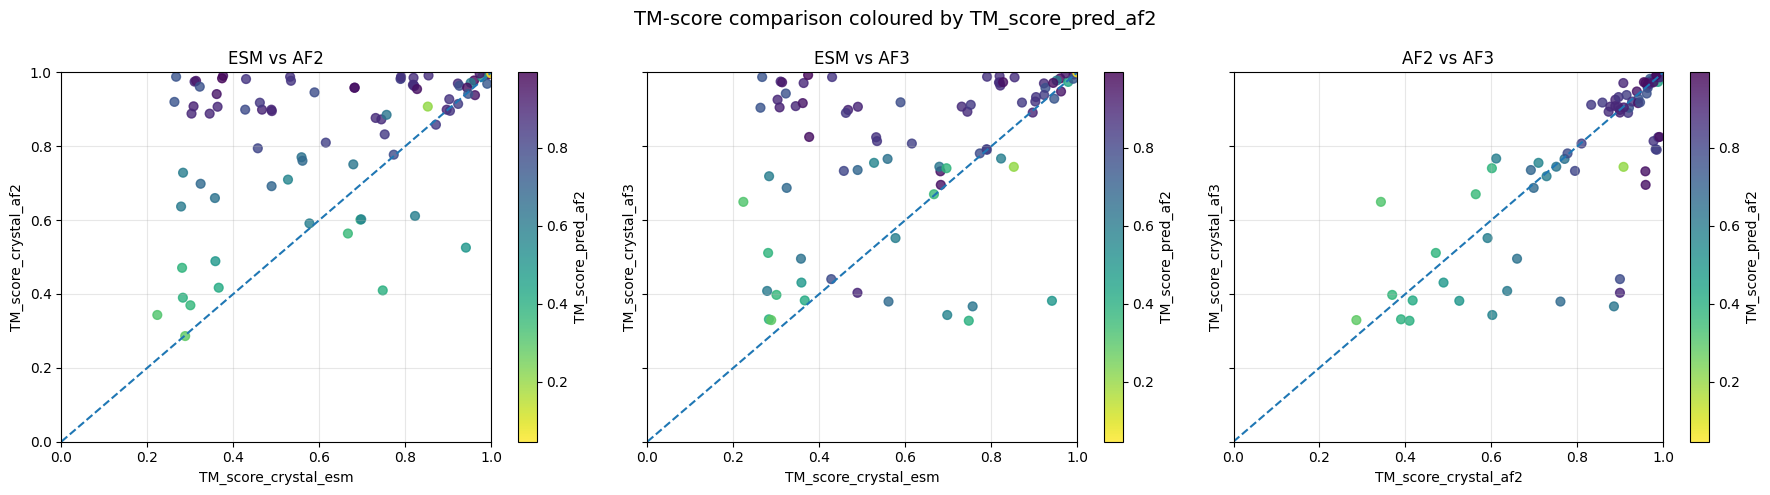

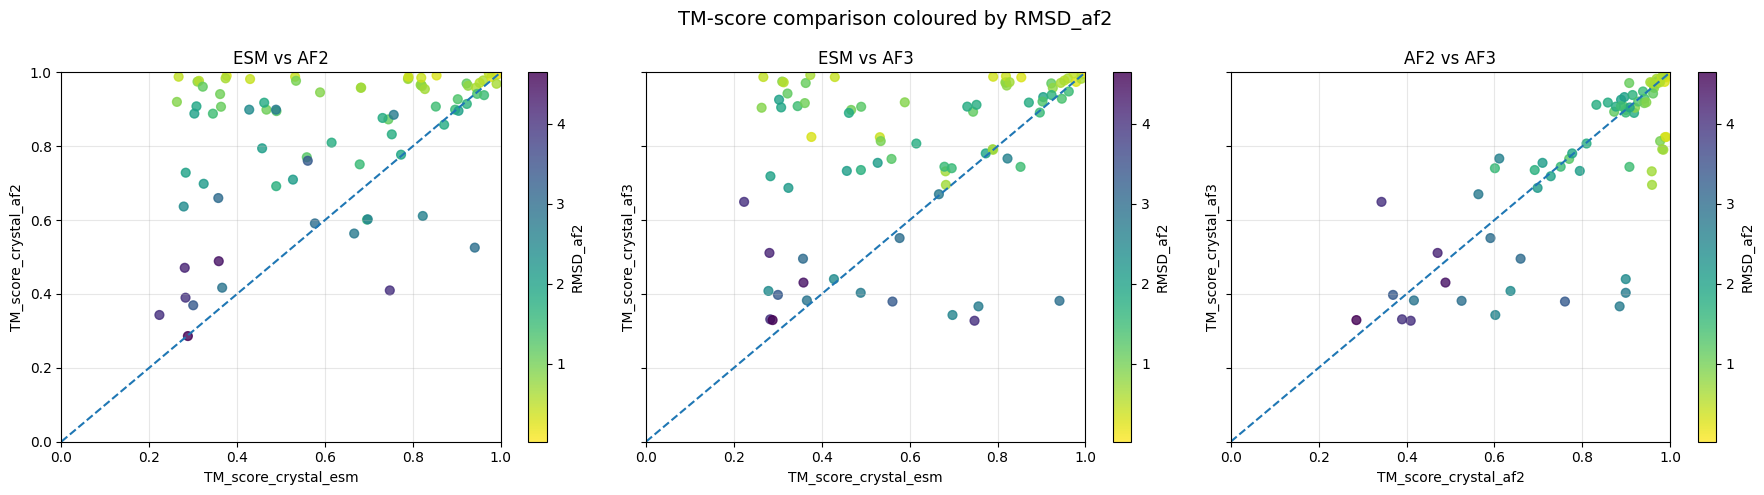

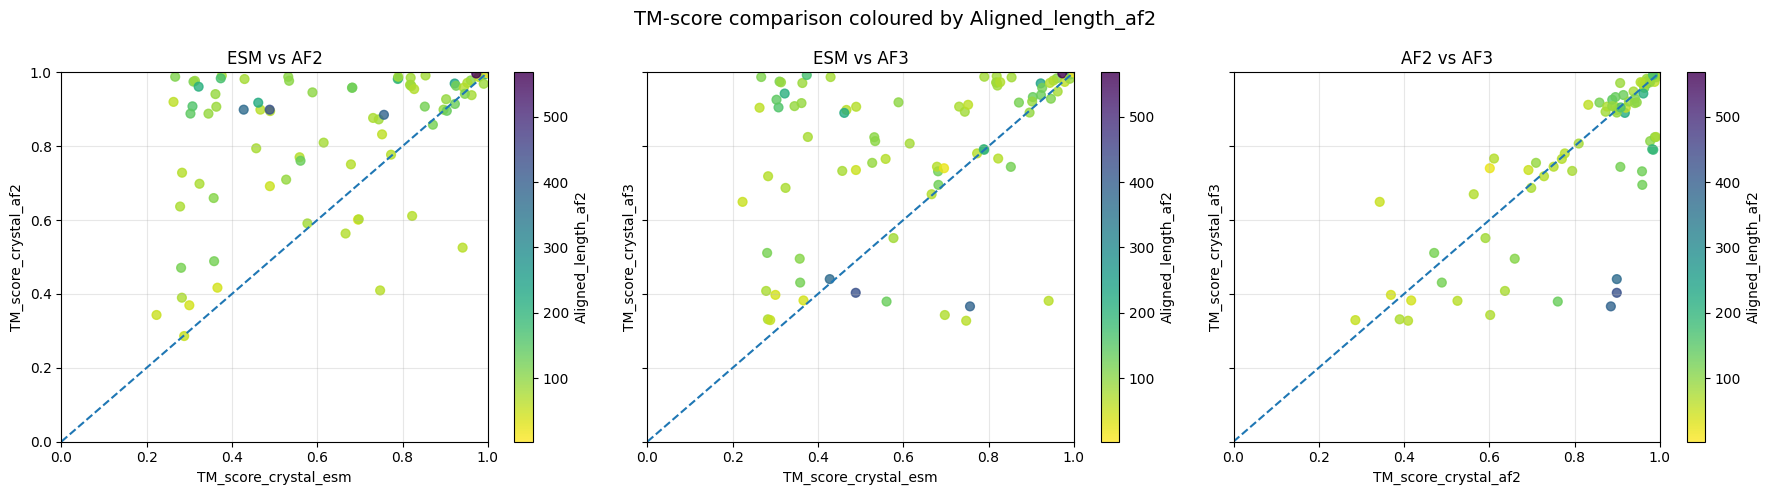

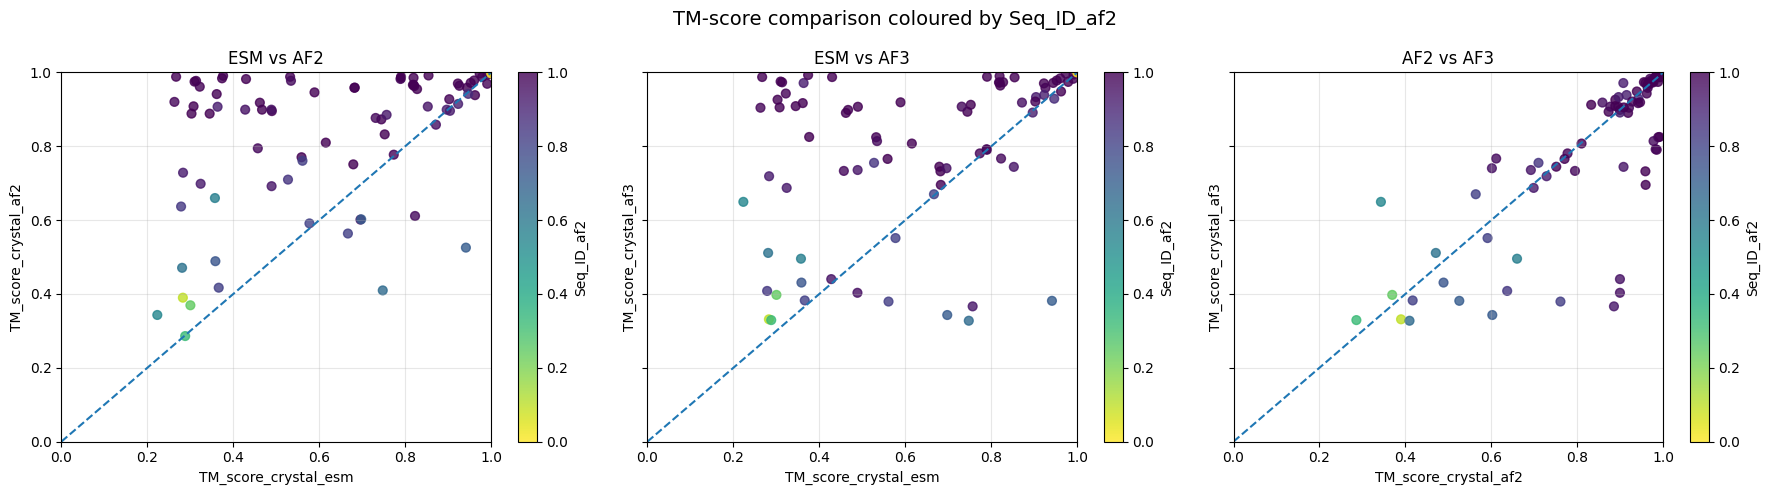

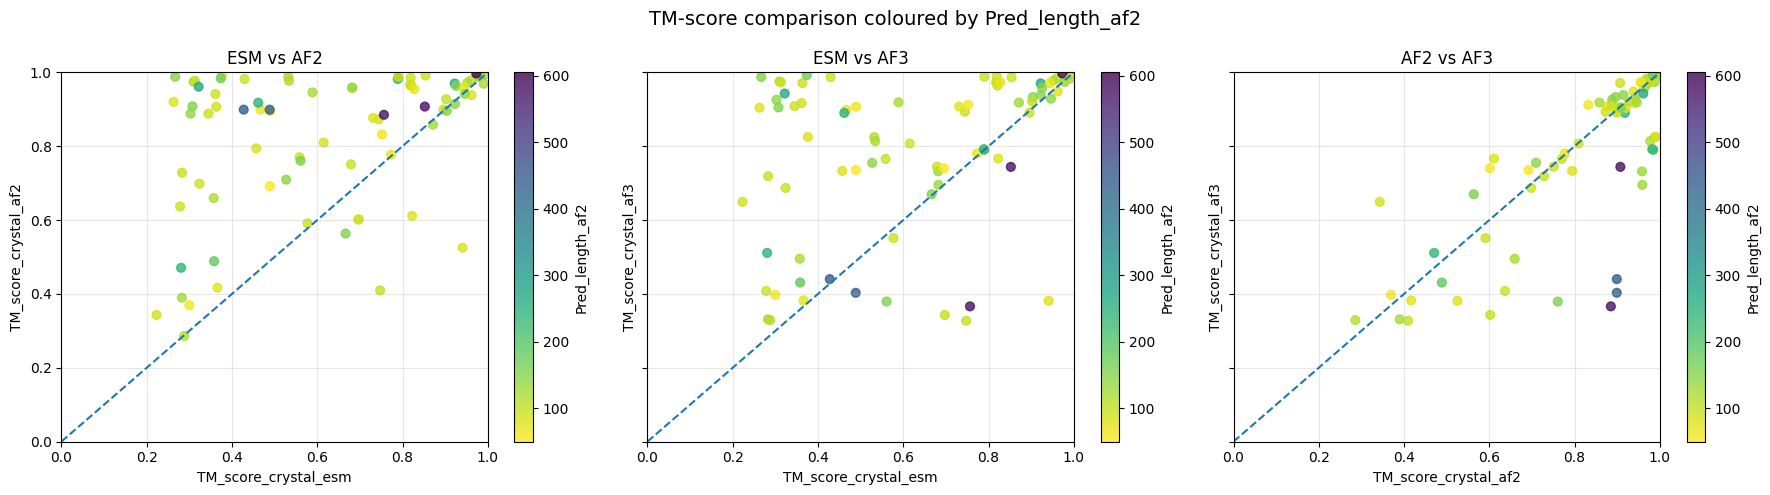

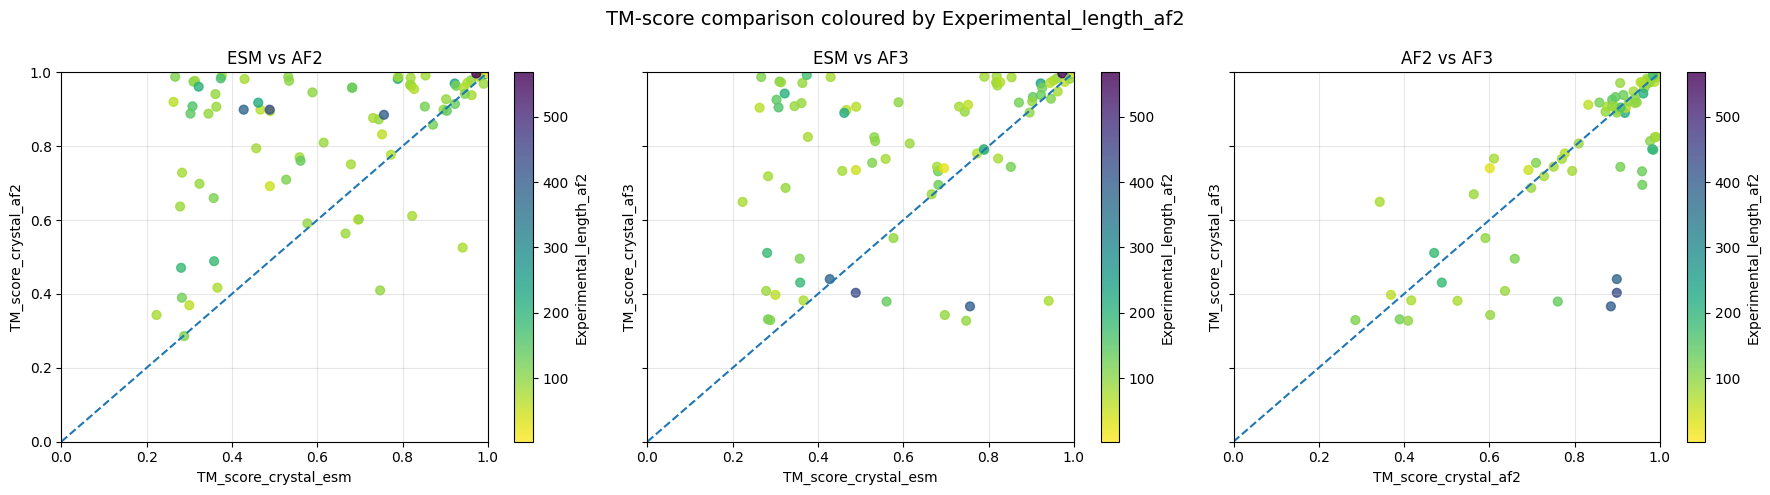

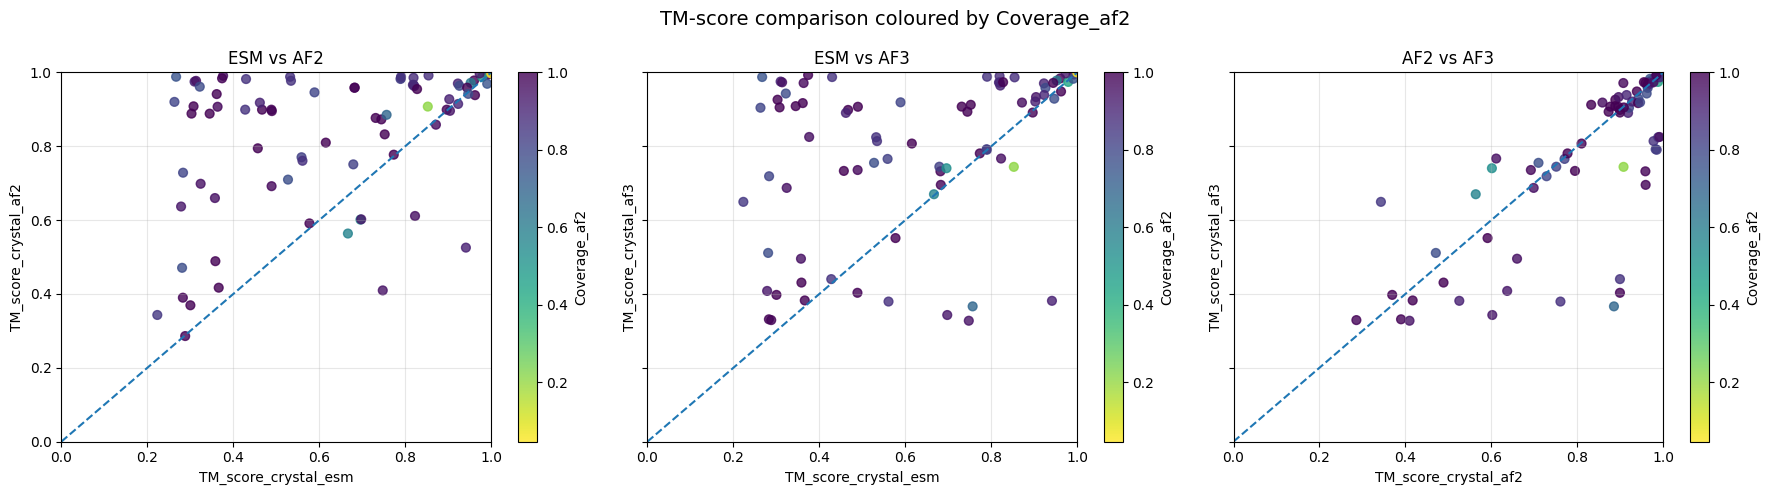

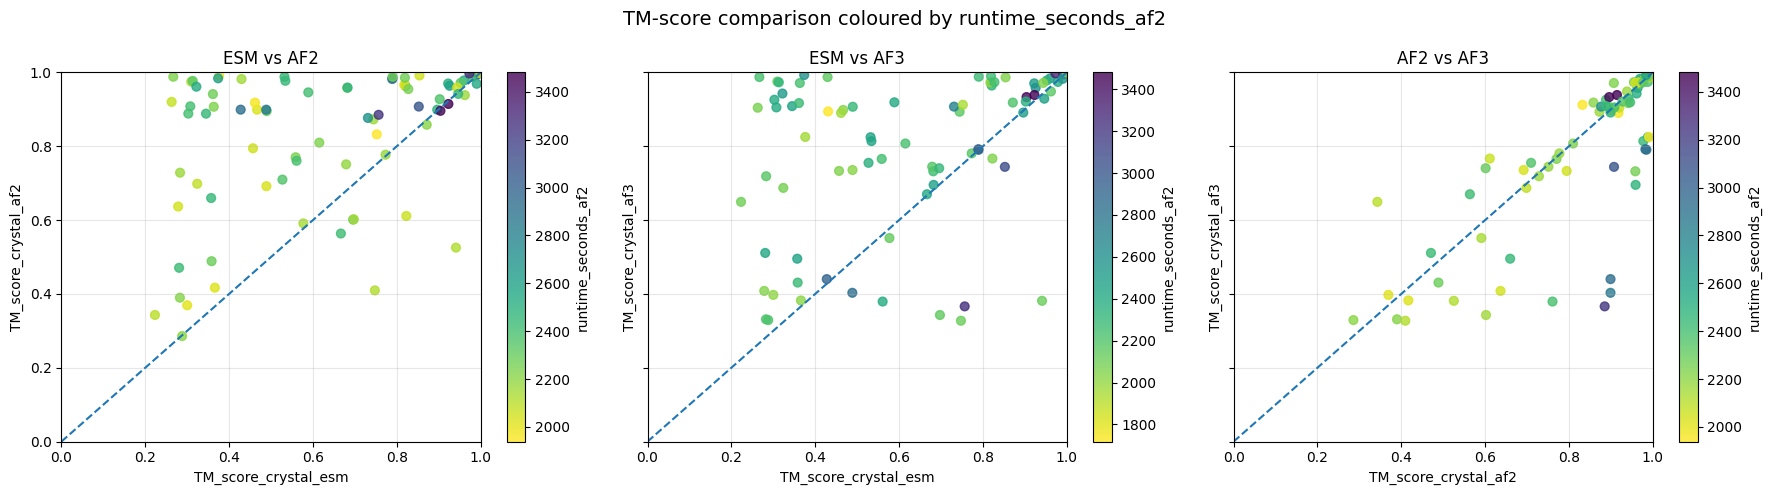

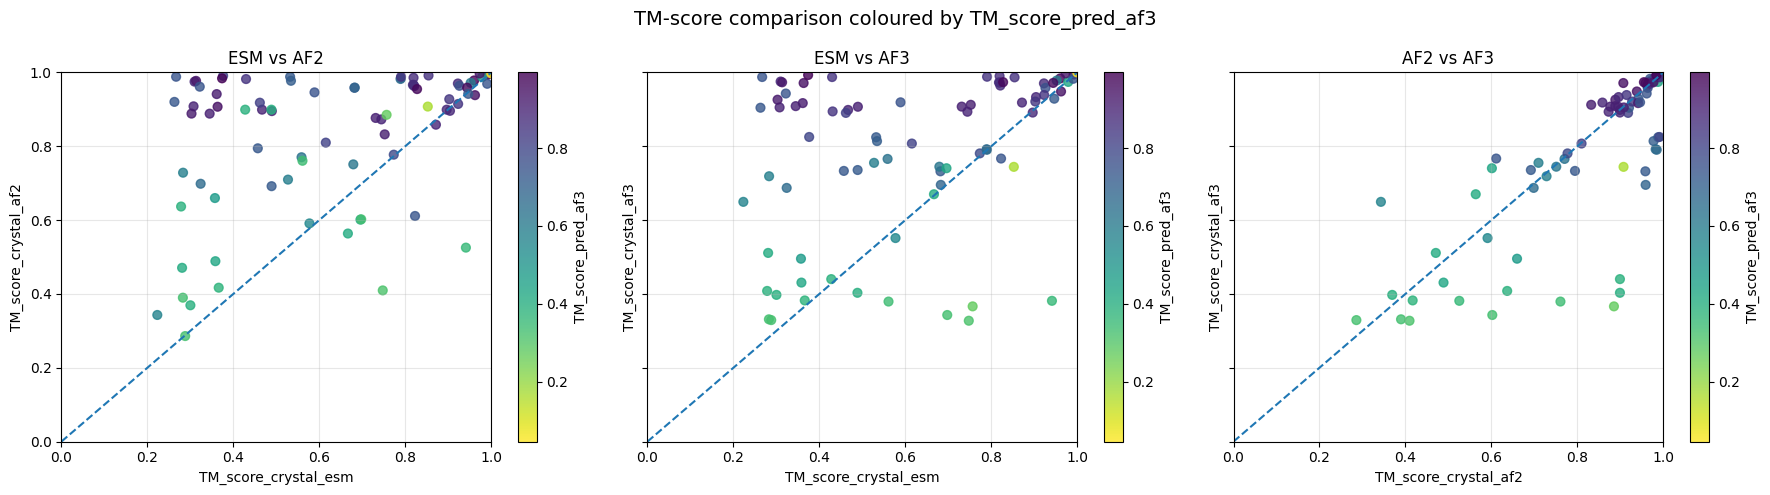

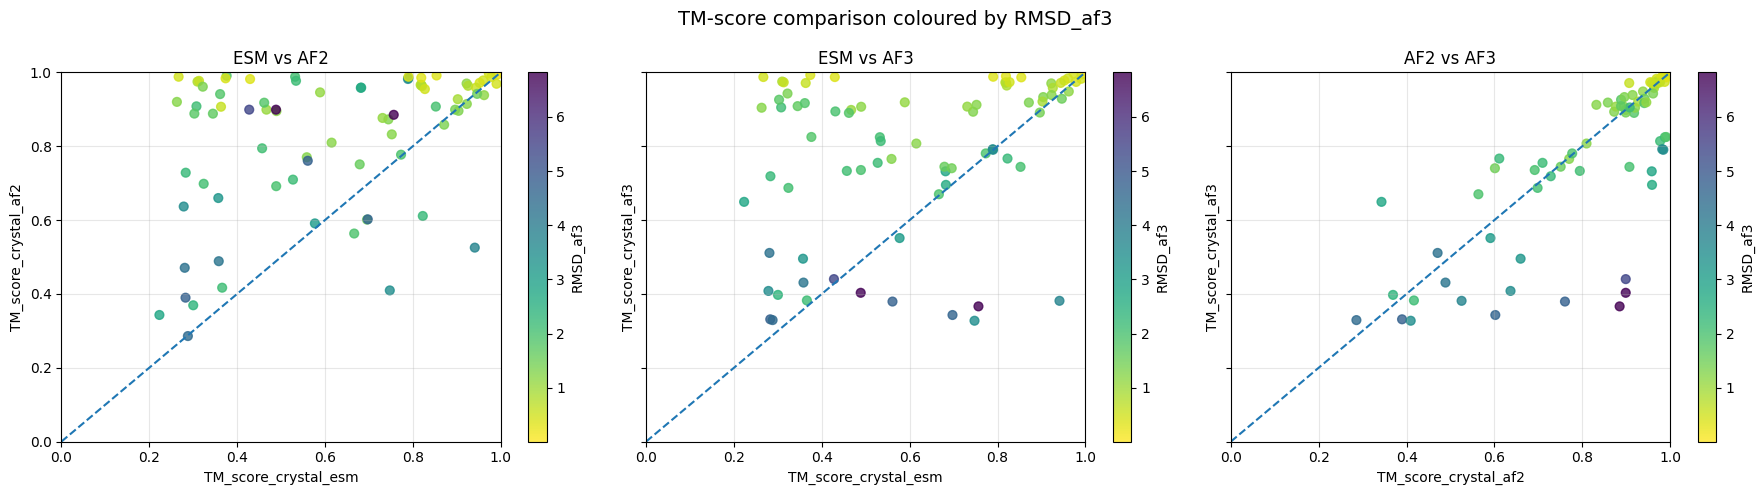

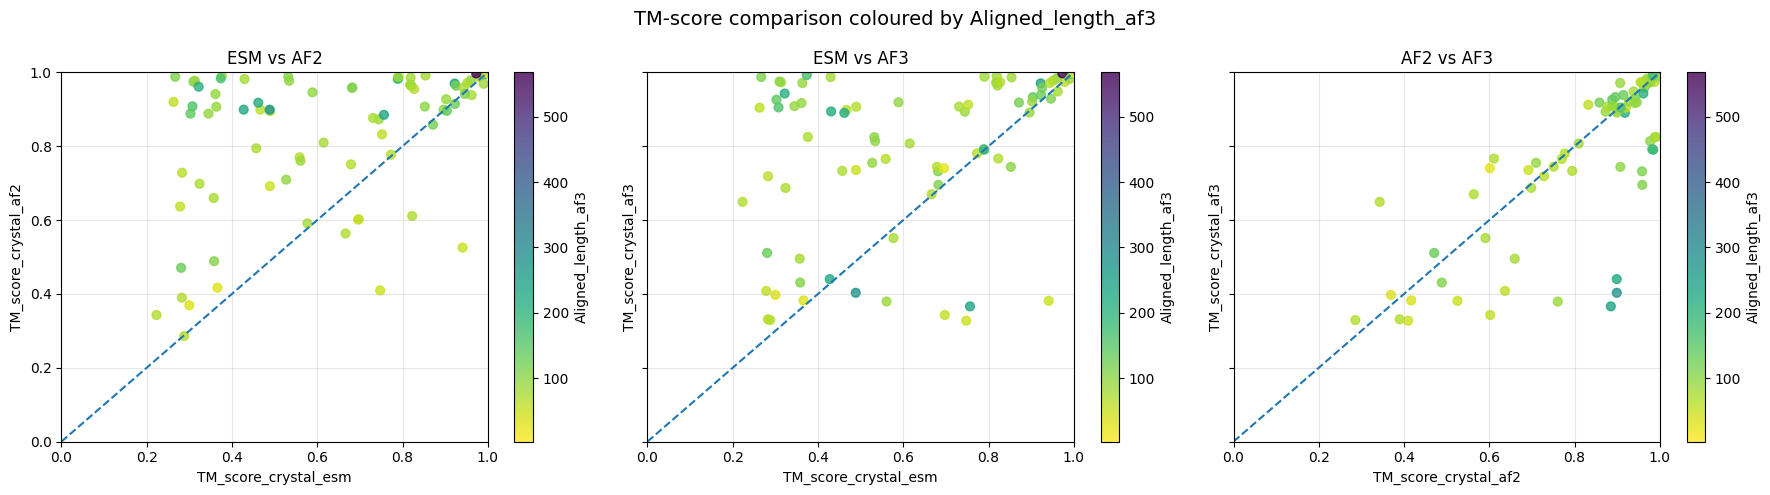

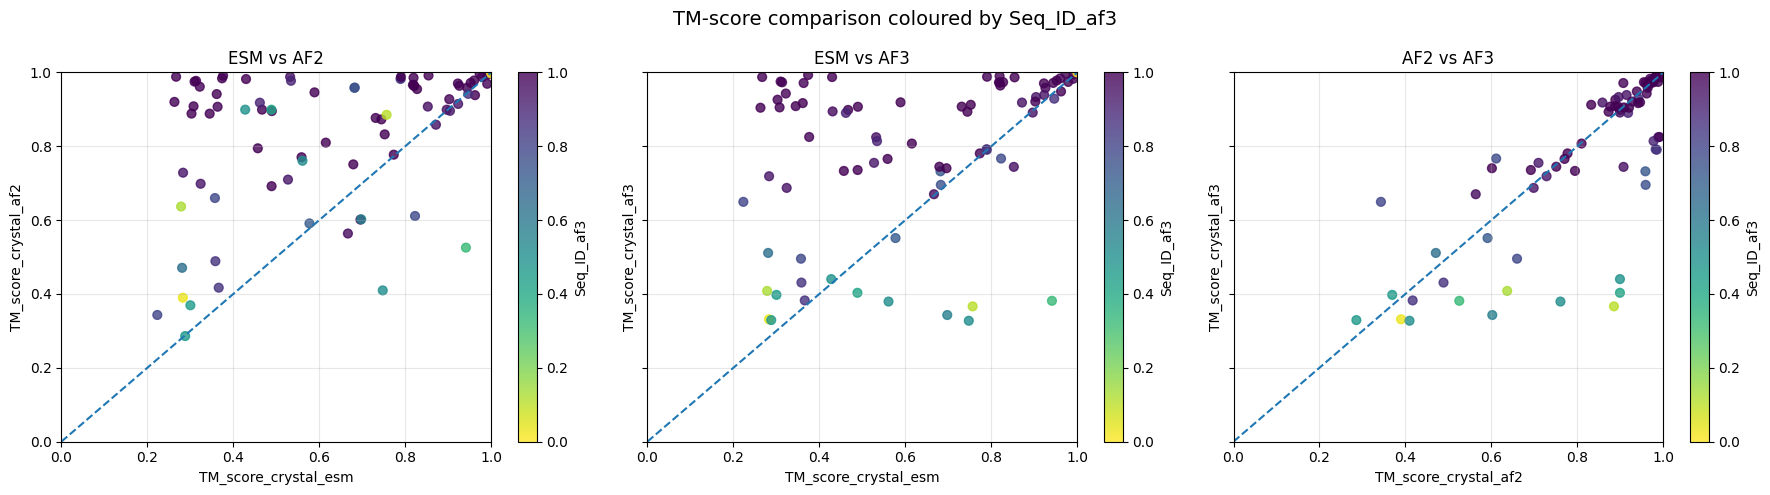

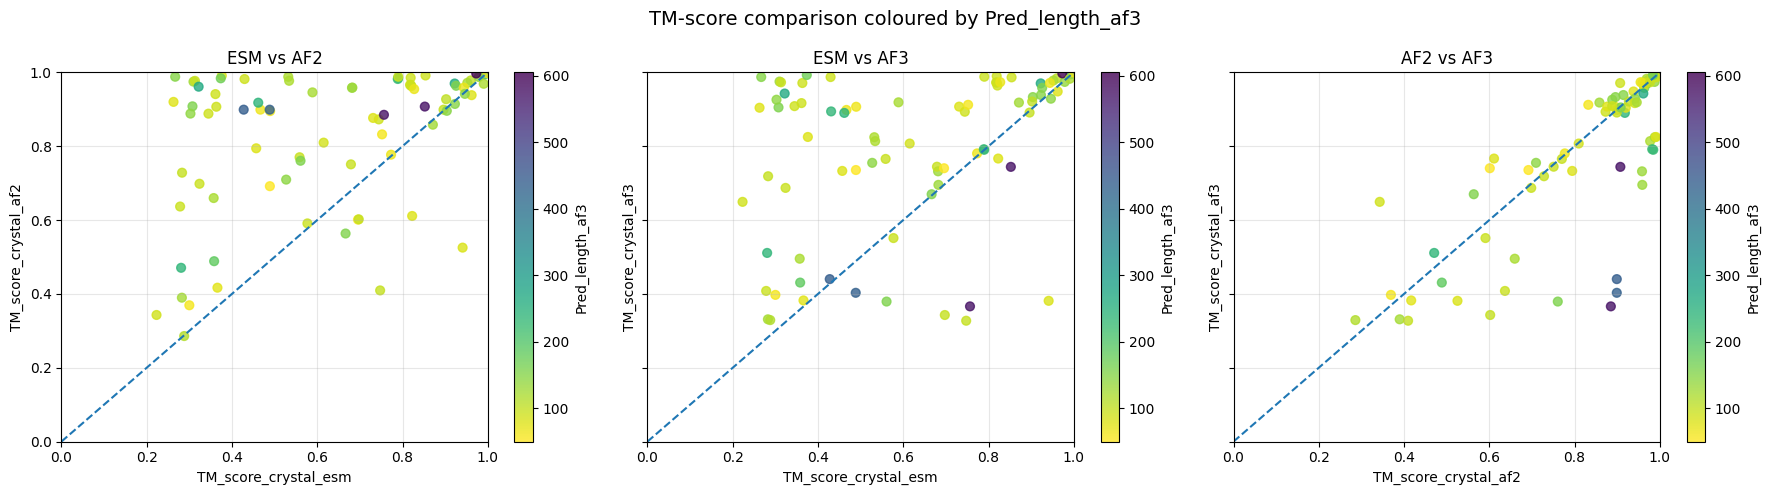

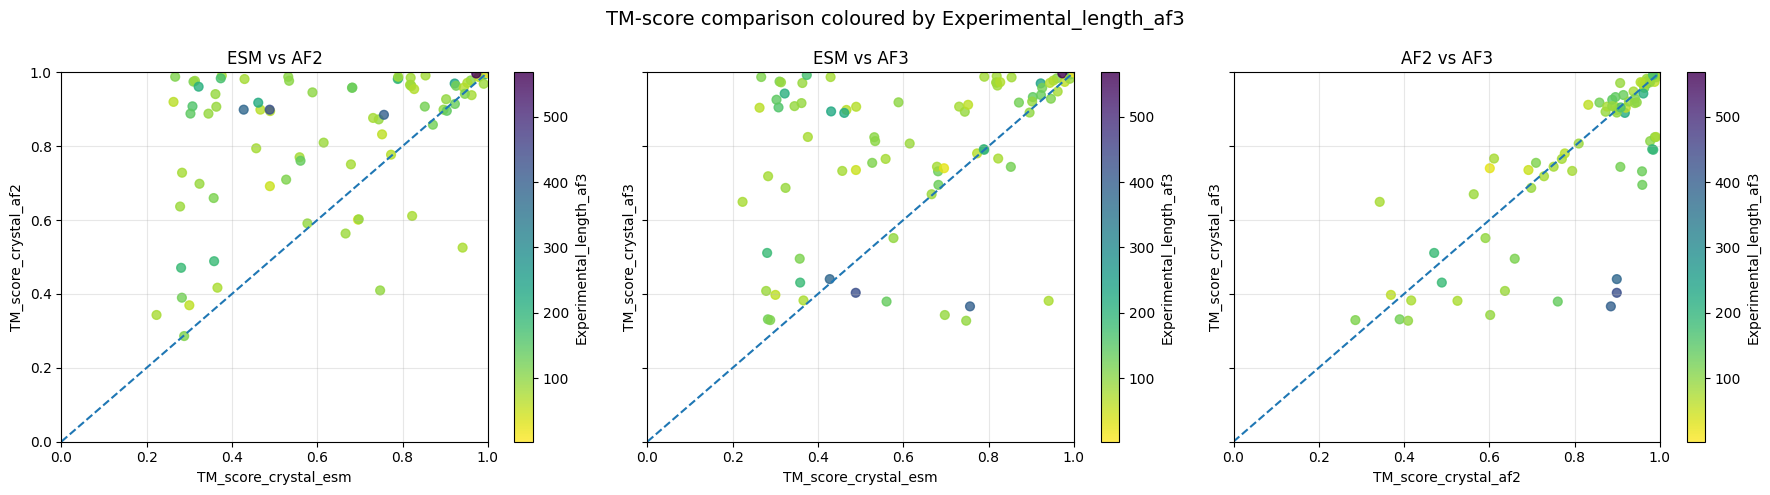

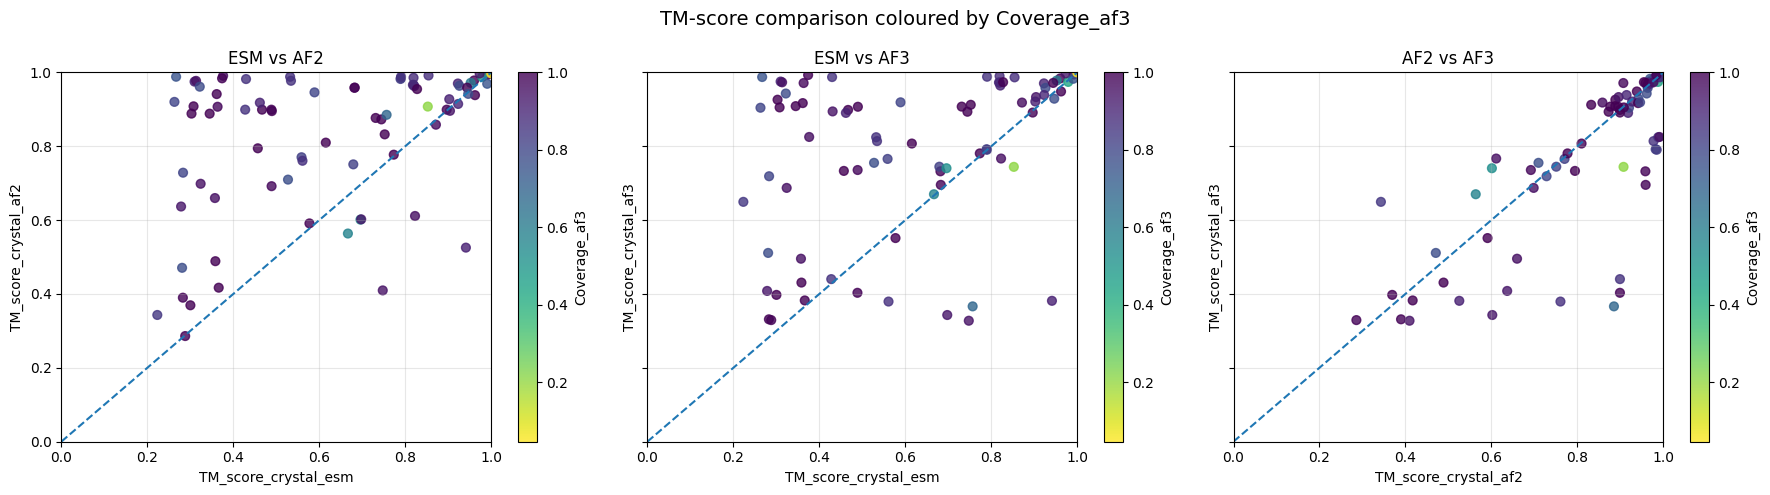

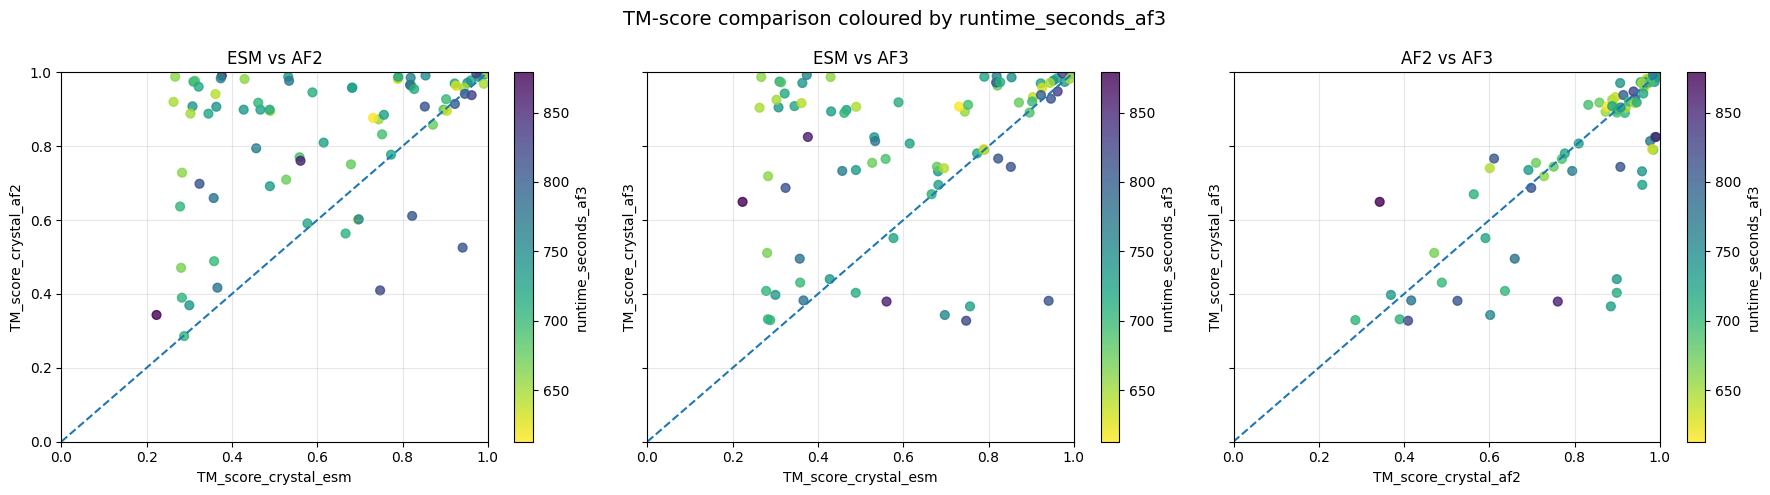

In [16]:
# Plot continuous data 
df["Deposition_year"] = pd.to_datetime(
    df["Deposition_date"]
).dt.year

df["Resolution"] = pd.to_numeric(
    df["Resolution"],
    errors="coerce"
)
continuous_metadata = [
    'Deposition_year',
    'How many protein identities in crystal structure',
    'Resolution', 'TM_score_pred_esm', 'RMSD_esm',
    'Aligned_length_esm', 'Seq_ID_esm', 'Pred_length_esm',
    'Experimental_length_esm', 'Coverage_esm', 'runtime_seconds_esm',
    'TM_score_pred_af2', 'RMSD_af2',
    'Aligned_length_af2', 'Seq_ID_af2', 'Pred_length_af2',
    'Experimental_length_af2', 'Coverage_af2', 'runtime_seconds_af2',
    'TM_score_pred_af3', 'RMSD_af3', 'Aligned_length_af3', 'Seq_ID_af3',
    'Pred_length_af3', 'Experimental_length_af3', 'Coverage_af3',
    'runtime_seconds_af3'
    ]

for colour_column in continuous_metadata:

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        scatter = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[colour_column],
            cmap="viridis_r",
            s=40,
            alpha=0.8
        )

        cbar = plt.colorbar(
            scatter,
            ax=ax
        )

        cbar.set_label(colour_column)

        # diagonal = equal performance
        ax.plot(
            [0, 1],
            [0, 1],
            "--"
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)

        ax.set_title(title)

        ax.grid(alpha=0.3)

    fig.suptitle(
        f"TM-score comparison coloured by {colour_column}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()
    plt.close()

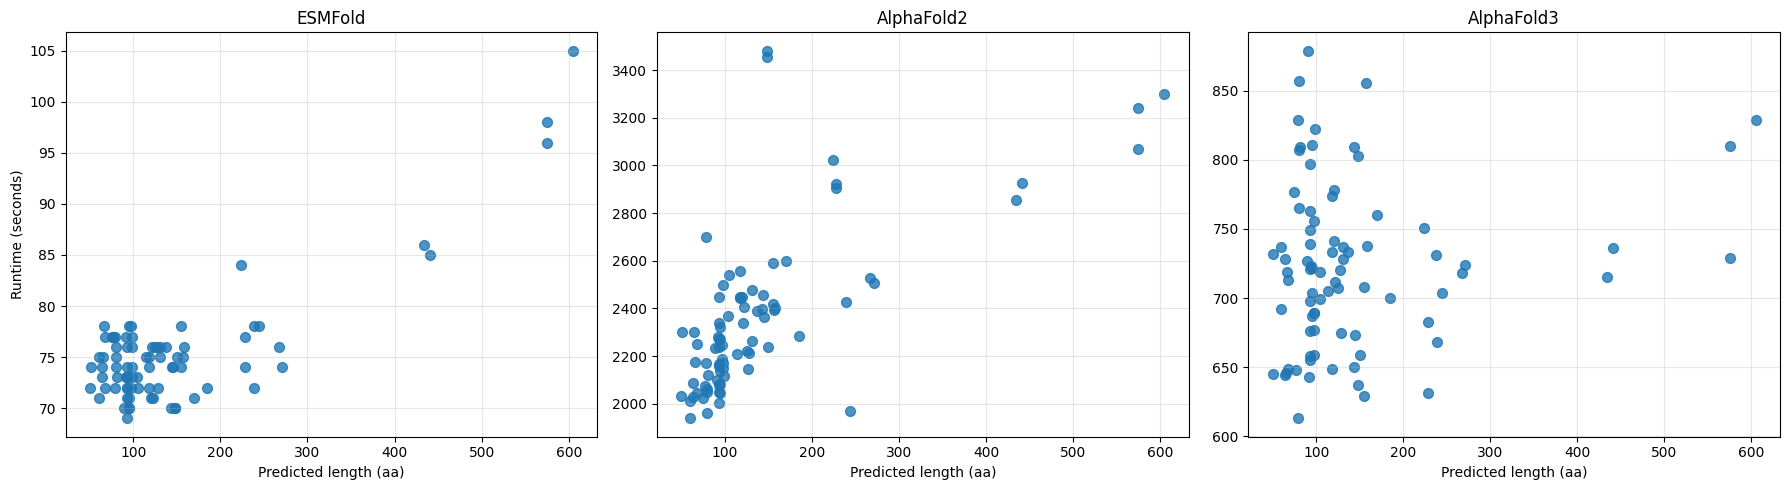

In [17]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18,5),
)

models = [
    ("Pred_length_esm", "runtime_seconds_esm", "ESMFold"),
    ("Pred_length_af2", "runtime_seconds_af2", "AlphaFold2"),
    ("Pred_length_af3", "runtime_seconds_af3", "AlphaFold3"),
]

for ax, (length_col, runtime_col, title) in zip(axes, models):

    ax.scatter(
        df[length_col],
        df[runtime_col],
        s=50,
        alpha=0.8
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted length (aa)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Runtime (seconds)")

plt.tight_layout()
plt.show()